Summary: This work employs out-of-distribution (OOD) data analysis to evaluate machine learning models for polarization prediction. In the first stage, we developed a Gaussian Process (GP) model by optimizing its key hyperparameters — length scale, coefficient, noise, and kernel type. The optimized parameters were then applied to the GP model for polarization prediction. In parallel, we trained a Multilayer Perceptron (MLP) model for the same task. After developing both models, we performed OOD analysis by systematically varying the frequency beyond the training range — both above and below the frequency threshold. This allowed us to examine and compare the performance and behavior of the GP and MLP models under OOD conditions.


GP: Hyperparameter optimization

In [1]:
# Hyper-parameters GP (No Bound)
import numpy as np
import tensorflow as tf
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
import pandas as pd

class GPHyperOpt:
    def __init__(self, kernel="laplace"):
        self.kernel = kernel
        self.log_lengthscale = tf.Variable(np.log(1.0), dtype=tf.float64)  # Initial guess
        self.log_coefficient = tf.Variable(np.log(1.0), dtype=tf.float64)  # Initial guess
        self.log_noise = tf.Variable(np.log(0.01), dtype=tf.float64)       # Initial guess
        self.scaler_X = None
        self.scaler_y = None
        self.X_train = None
        self.y_train = None

    def _covariance(self, x1, x2, noise=False):
        x1 = tf.convert_to_tensor(x1, dtype=tf.float64)
        x2 = tf.convert_to_tensor(x2, dtype=tf.float64)
        diff = tf.expand_dims(x1, 1) - tf.expand_dims(x2, 0)
        l = tf.exp(self.log_lengthscale)
        c = tf.exp(self.log_coefficient)

        if self.kernel == "laplace":
            l1 = tf.reduce_sum(tf.abs(diff / l), axis=2)
            cov = c**2 * tf.exp(-0.5 * l1)
        elif self.kernel == "eq":
            l2 = tf.reduce_sum((diff / l) ** 2, axis=2)
            cov = c**2 * tf.exp(-0.5 * l2)
        elif self.kernel == "cauchy":
            l2 = tf.reduce_sum((diff ** 2), axis=2)
            cov = c**2 / (1.0 + l2 / (l ** 2))
        else:
            raise ValueError("Unknown kernel")

        if noise:
            cov += tf.exp(self.log_noise) ** 2 * tf.eye(tf.shape(cov)[0], dtype=tf.float64)
        return cov

    def fit(self, X_train, y_train, methods):
        # Normalize
        self.scaler_X = StandardScaler()
        self.X_train = self.scaler_X.fit_transform(X_train)
        self.scaler_y = StandardScaler()
        self.y_train = self.scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

        results = {}

        def nll(params):
            self.log_lengthscale.assign(params[0])
            self.log_coefficient.assign(params[1])
            self.log_noise.assign(params[2])
            K = self._covariance(self.X_train, self.X_train, noise=True)
            L = tf.linalg.cholesky(K)
            alpha = tf.linalg.cholesky_solve(L, self.y_train[:, None])
            nll_value = (
                0.5 * tf.matmul(tf.transpose(self.y_train[:, None]), alpha)
                + tf.reduce_sum(tf.math.log(tf.linalg.diag_part(L)))
                + 0.5 * len(self.y_train) * np.log(2 * np.pi)
            )
            return nll_value.numpy().flatten()[0]

        x0 = [self.log_lengthscale.numpy(), self.log_coefficient.numpy(), self.log_noise.numpy()]

        for method in methods:
            try:
                res = minimize(nll, x0, method=method)
                results[method] = {
                "loss": res.fun,                 # store the minimized negative log-likelihood
                "hyperparameters": np.exp(res.x) # store the optimized hyperparameters
                }
            except Exception as e:
                 results[method] = f"Failed ({e})"


        return results


# ---------------- Main ----------------
if __name__ == "__main__":
    # Load and prepare data
    data = pd.read_csv("/Users/monibor/Desktop/polarized_proton_data_with_current.csv")
    filtered_data = data[data["SampleID"] == "(P07)"]
    X = filtered_data[["scaler_calc1", "uwave_freq", "TGT:PT12:Target_Dose"]].values
    y = filtered_data["polarization"].values

    # Split data
    dataset_size = X.shape[0]
    tf.random.set_seed(42)
    indices = tf.random.shuffle(tf.range(dataset_size), seed=42)
    split = int(0.8 * dataset_size)
    train_idx = indices[:split]
    X_train = X[train_idx]
    y_train = y[train_idx]

    # Optimization methods to compare
    methods = ["Powell", "Nelder-Mead", "L-BFGS-B", "CG", "COBYQA"]

    # Run for different kernels
    for kernel in ["laplace", "eq", "cauchy"]:
        print(f"\n{'='*60}\nKernel: {kernel.upper()}\n{'='*60}")
        gp = GPHyperOpt(kernel=kernel)
        results = gp.fit(X_train, y_train, methods)
        for method, info in results.items():
            if isinstance(info, dict):
                print(f"{method:12s} → Loss: {info['loss']:.4f} | Optimized hyperparameters (lengthscale, coefficient, noise): {info['hyperparameters']}")
            else:
                print(f"{method:12s} → {info}")


Kernel: LAPLACE
Powell       → Loss: -237.4318 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.07521149e+03 2.72977608e+01 1.13929847e-01]
Nelder-Mead  → Loss: -237.4324 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.12172846e+03 2.79079435e+01 1.13792692e-01]
L-BFGS-B     → Loss: -237.4321 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.14351480e+03 2.81381205e+01 1.13826456e-01]
CG           → Loss: -237.4307 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.26682441e+03 2.96724072e+01 1.13784514e-01]
COBYQA       → Loss: -237.4324 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.12215796e+03 2.79133039e+01 1.13792160e-01]

Kernel: EQ
Powell       → Loss: -119.7784 | Optimized hyperparameters (lengthscale, coefficient, noise): [0.64959483 1.1323601  0.17416614]
Nelder-Mead  → Loss: -116.6511 | Optimized hyperparameters (lengthscale, coefficient, noise): [0.79617211 1.73293312 0.17475732]
L-BFGS-B

GP Model development

/var/folders/f7/ctknnb4x36jgpz3vdy9mhydc000_br/T/ipykernel_28186/1835483607.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data[col] = pd.to_datetime(filtered_data[col], errors='coerce')
/var/folders/f7/ctknnb4x36jgpz3vdy9mhydc000_br/T/ipykernel_28186/1835483607.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data[col] = pd.to_datetime(filtered_data[col], errors='coerce')
/var/folders/f7/ctknnb4x36jgpz3vdy9mhydc000_br/T/ipykernel_28186/1835483607.py:105: SettingWithCopyWarning: 

R²: 0.985


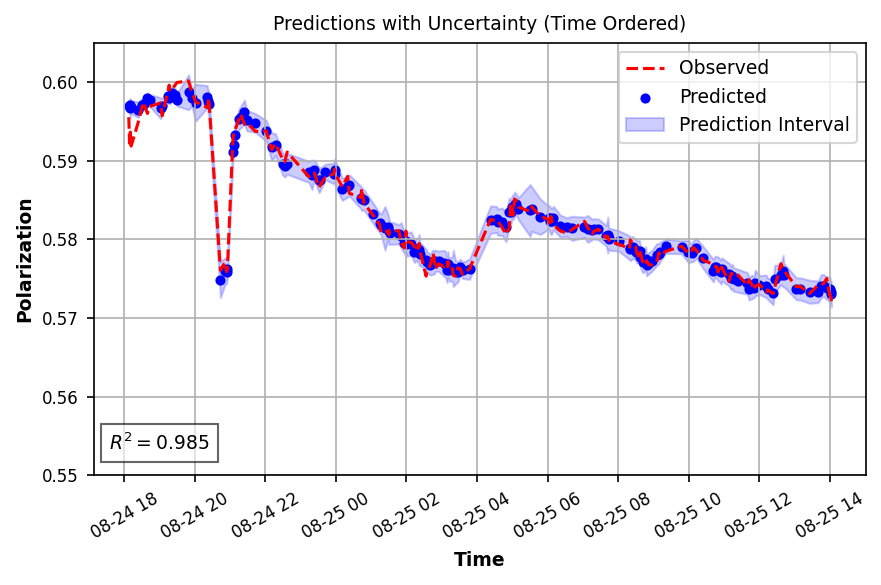

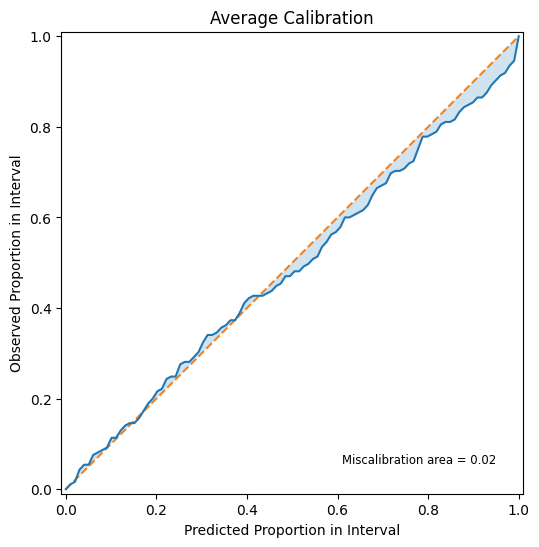

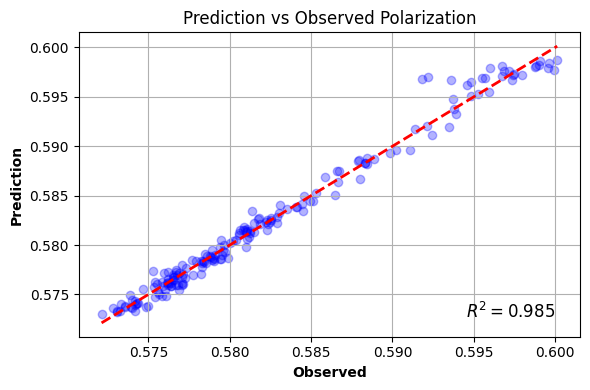

In [2]:
# ------------------------
# 0. Imports
# ------------------------
import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import uncertainty_toolbox as uct

# ------------------------
# 1. GP Model Class
# ------------------------
class GPModelTF:
    def __init__(self, kernel="laplace", lengthscale=1.0, coefficient=1.0, noise=1e-2):
        self.kernel = kernel
        self.lengthscale = lengthscale
        self.coefficient = coefficient
        self.noise = noise
        self.scaler_X = None
        self.scaler_y = None
        self.X_train_norm = None
        self.y_train_norm = None

    def _covariance(self, x1, x2, noise=None):
        x1 = tf.convert_to_tensor(x1, dtype=tf.float64)
        x2 = tf.convert_to_tensor(x2, dtype=tf.float64)
        diff = tf.expand_dims(x1, 1) - tf.expand_dims(x2, 0)

        if self.kernel == "eq":
            l2 = tf.reduce_sum((diff / self.lengthscale)**2, axis=2)
            cov = self.coefficient**2 * tf.exp(-0.5 * l2)
        elif self.kernel == "laplace":
            l1 = tf.reduce_sum(tf.abs(diff / self.lengthscale), axis=2)
            cov = self.coefficient**2 * tf.exp(-0.5 * l1)
        elif self.kernel == "cauchy":
            l2 = tf.reduce_sum((diff / self.lengthscale)**2, axis=2)
            cov = self.coefficient**2 / (1.0 + l2)
        else:
            raise ValueError("Unknown kernel type")

        if noise is not None:
            cov += noise**2 * tf.eye(tf.shape(cov)[0], dtype=tf.float64)
        return cov

    def fit(self, X_train, y_train):
        self.scaler_X = StandardScaler()
        self.X_train_norm = self.scaler_X.fit_transform(X_train)

        self.scaler_y = StandardScaler()
        self.y_train_norm = self.scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

    def predict(self, X_new):
        X_new_norm = self.scaler_X.transform(X_new)
        Kdd = self._covariance(self.X_train_norm, self.X_train_norm, noise=self.noise)
        Kpd = self._covariance(X_new_norm, self.X_train_norm)
        Kpp = self._covariance(X_new_norm, X_new_norm)

        alpha = tf.linalg.solve(Kdd, tf.expand_dims(self.y_train_norm, axis=1))
        mean_norm = tf.matmul(Kpd, alpha)[:, 0]
        cov = Kpp - tf.matmul(Kpd, tf.linalg.solve(Kdd, tf.transpose(Kpd)))
        var_norm = tf.linalg.diag_part(cov)

        mean_orig = self.scaler_y.inverse_transform(mean_norm.numpy().reshape(-1, 1)).flatten()
        std_orig = (var_norm.numpy()**0.5) * self.scaler_y.scale_
        return mean_orig, std_orig

# ------------------------
# 2. Load and Prepare Data
# ------------------------
data = pd.read_csv("/Users/monibor/Desktop/polarized_proton_data_with_current.csv")
filtered_data = data[data['SampleID'] == '(P07)']

for col in ['start_time', 'end_time']:
    if col in filtered_data.columns:
        filtered_data[col] = pd.to_datetime(filtered_data[col], errors='coerce')

New_data = filtered_data[['uwave_freq', 'TGT:PT12:Target_Dose', 'scaler_calc1', 'polarization']]
X = New_data.iloc[:, 0:3].values
y = New_data.iloc[:, -1].values

# ------------------------
# 3. Train/Test Split
# ------------------------
dataset_size = X.shape[0]
tf.random.set_seed(42)
shuffled_indices = tf.random.shuffle(tf.range(dataset_size), seed=42)

split = int(0.8 * dataset_size)
train_idx, test_idx = shuffled_indices[:split], shuffled_indices[split:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# ------------------------
# 4. Fit GP Model
# ------------------------
gp_model = GPModelTF(kernel="laplace", lengthscale=1143.518, coefficient=28.13, noise=0.113) # LAPLACE L-BFGS-B
gp_model.fit(X_train, y_train)
mean_pred, std_pred = gp_model.predict(X_test)

filtered_test = filtered_data.iloc[test_idx]
filtered_test['Polarization_Prediction'] = mean_pred
filtered_test['Polarization_Prediction_std'] = std_pred

if 'start_time' in filtered_test.columns:
    filtered_test = filtered_test.sort_values('start_time').reset_index(drop=True)

# ------------------------
# 5. R² Calculation
# ------------------------
r2 = r2_score(filtered_test['polarization'], filtered_test['Polarization_Prediction'])
print(f"R²: {r2:.3f}")

# ------------------------
# 6. Time Series Plot with Uncertainty
# ------------------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.plot(filtered_test['start_time'], filtered_test['polarization'], 'r--', label='Observed')
ax.scatter(filtered_test['start_time'], filtered_test['Polarization_Prediction'], s=15, color='blue', label='Predicted')
ax.fill_between(
    filtered_test['start_time'],
    filtered_test['Polarization_Prediction'] - 2*filtered_test['Polarization_Prediction_std'],
    filtered_test['Polarization_Prediction'] + 2*filtered_test['Polarization_Prediction_std'],
    color='blue', alpha=0.2, label='Prediction Interval'
)
ax.set_xlabel("Time", fontsize=9, fontweight='bold')
ax.set_ylabel("Polarization", fontsize=9, fontweight='bold')
ax.set_title("Predictions with Uncertainty (Time Ordered)", fontsize=9)
ax.set_ylim(0.55, 0.605)
ax.legend(fontsize=9)
ax.tick_params(axis='x', labelsize=8, rotation=30)
ax.tick_params(axis='y', labelsize=8)
ax.grid(True)
ax.text(0.02, 0.05, f"$R^2 = {r2:.3f}$", transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.6))
plt.tight_layout()
plt.show()

# ------------------------
# 7. Average Calibration Plot
# ------------------------
uct.viz.plot_calibration(
    filtered_test['Polarization_Prediction'].values,
    filtered_test['Polarization_Prediction_std'].values,
    filtered_test['polarization'].values
)
plt.gcf().set_size_inches(6, 6)
plt.title("Average Calibration")
plt.show()

# ------------------------
# 8. Prediction vs Observed Scatter Plot
# ------------------------
plt.figure(figsize=(6, 4))
plt.scatter(filtered_test['polarization'], filtered_test['Polarization_Prediction'], alpha=0.3, color='blue')
plt.plot(
    [filtered_test['polarization'].min(), filtered_test['polarization'].max()],
    [filtered_test['polarization'].min(), filtered_test['polarization'].max()],
    'r--', lw=2
)
plt.text(0.95, 0.05, f"$R^2 = {r2:.3f}$", transform=plt.gca().transAxes,
         fontsize=12, horizontalalignment='right', verticalalignment='bottom')
plt.xlabel("Observed", fontweight='bold')
plt.ylabel("Prediction", fontweight='bold')
plt.title("Prediction vs Observed Polarization")
plt.grid(True)
plt.tight_layout()
plt.show()

##-------------------------------------
## 9.  Save model
##-----------------------------------
# with open("/Users/monibor/Desktop/AIOP Target Optimization/untitled folder/GP/gp_model_tf_class_optimized.pkl", "wb") as f:
#     pickle.dump(gp_model, f)
# print("GP model saved to gp_model_tf_class.pkl")

MLP model development

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,730 (1.01 MB)

 Trainable params: 265,730 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4819 - val_loss: 0.1479
Epoch 2/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0208 - val_loss: -0.0508
Epoch 3/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.1370 - val_loss: -0.1813
Epoch 4/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.2653 - val_loss: -0.3243
Epoch 5/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.4101 - val_loss: -0.4800
Epoch 6/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.5547 - val_loss: -0.6090
Epoch 7/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.6803 - val_loss: -0.7264
Epoch 8/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.7660 - val_loss: -0.8297
Epoch 9/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.8201 - val_loss: -0.8270
Epoch 10/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.8370 - val_loss: -0.9001
Epoch 11/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.8665 - val_loss: -0.8386
Epoch 12/1000
19/19 ━━━━━━━━━━━━━

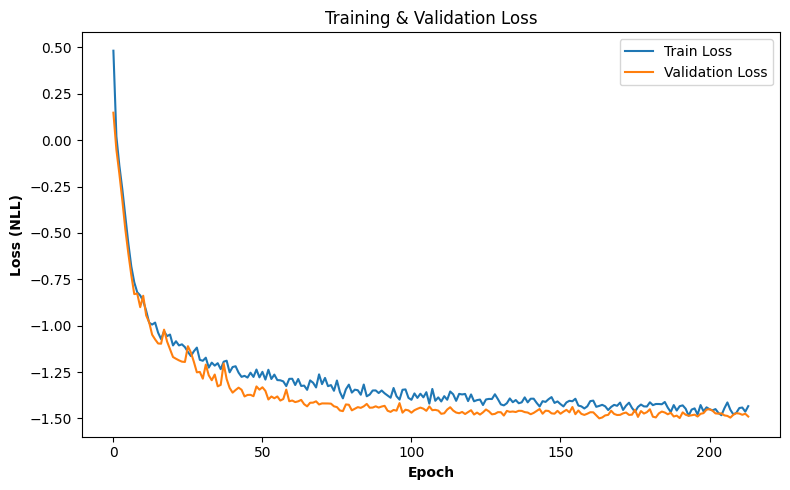

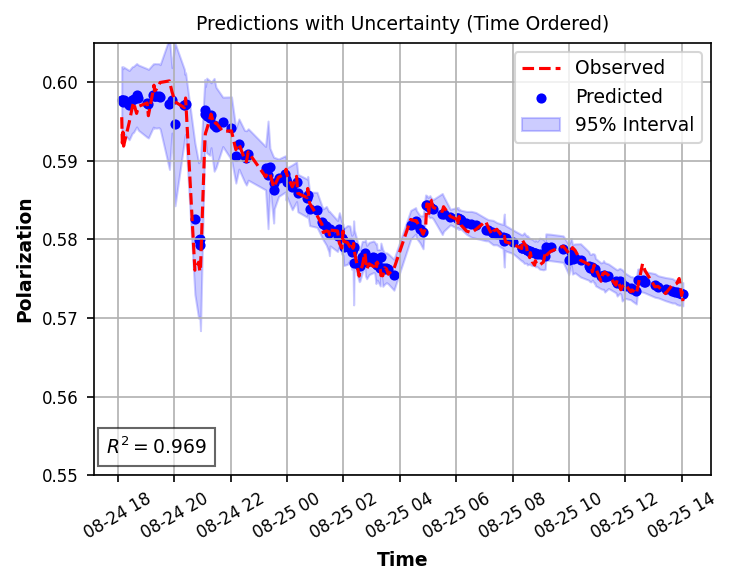

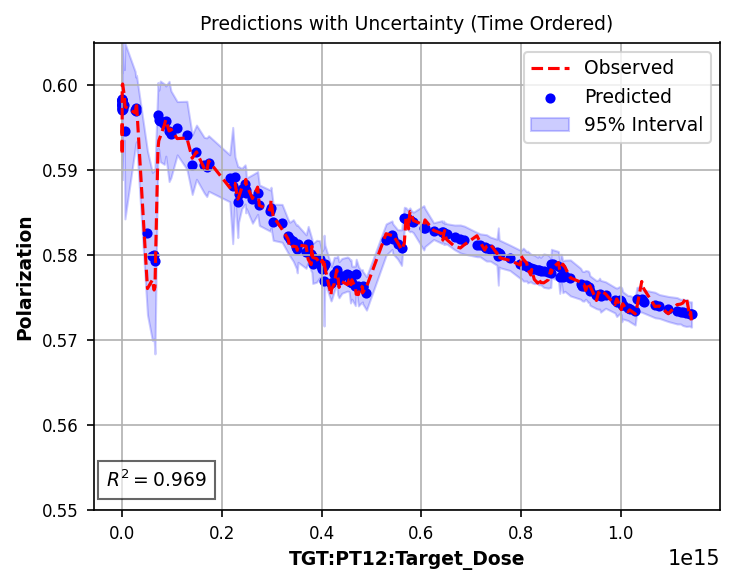

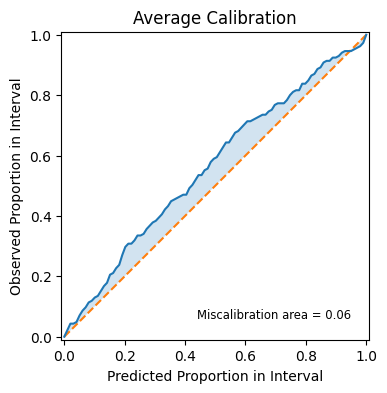

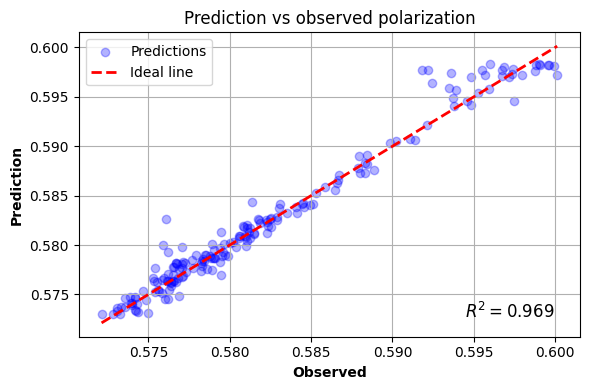

In [3]:
# ------------------------
# 0. Imports
# ------------------------
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Normalization
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import uncertainty_toolbox as uct

# ------------------------
# 1. Load and prepare data
# ------------------------
polarized_proton = pd.read_csv("polarized_proton_data_with_current.csv")

# Filter sample P07
data = polarized_proton[polarized_proton['SampleID'].astype(str).str.strip() == '(P07)'].reset_index(drop=True)

# Convert time columns to datetime (keep invalids as NaT, no dropping here)
if 'start_time' in data.columns:
    data['start_time'] = pd.to_datetime(data['start_time'], errors='coerce')
if 'end_time' in data.columns:
    data['end_time'] = pd.to_datetime(data['end_time'], errors='coerce')

# Features and target
feature_cols = ['uwave_freq', 'TGT:PT12:Target_Dose', 'scaler_calc1']
target_col = 'polarization'

X = tf.convert_to_tensor(data[feature_cols].values, dtype=tf.float32)
y = tf.abs(tf.convert_to_tensor(data[target_col].values, dtype=tf.float32))

# ------------------------
# 2. Train-test split with reproducible seed
# ------------------------
dataset_size = X.shape[0]
indices = tf.range(dataset_size)

# reproducibility like random_state=42
tf.random.set_seed(42)
shuffled_indices = tf.random.shuffle(indices, seed=42)

split = int(0.8 * dataset_size)
train_indices = shuffled_indices[:split]
test_indices = shuffled_indices[split:]

# keep numpy indices for pandas
train_idx_np = train_indices.numpy()
test_idx_np = test_indices.numpy()

X_train, X_test = tf.gather(X, train_indices), tf.gather(X, test_indices)
y_train, y_test = tf.gather(y, train_indices), tf.gather(y, test_indices)

# ------------------------
# 3. Feature normalization
# ------------------------
normalizer = Normalization(axis=-1)
normalizer.adapt(X_train)

X_train_scaled = normalizer(X_train)
X_test_scaled = normalizer(X_test)

# Target normalization
y_mean = tf.reduce_mean(y_train)
y_std = tf.math.reduce_std(y_train)
y_train_scaled = (y_train - y_mean) / y_std

# ------------------------
# 4. Define NLL Gaussian loss
# ------------------------
def nll_gaussian(y_true, y_pred):
    mean = y_pred[:, 0]
    log_var = tf.clip_by_value(y_pred[:, 1], -10.0, 10.0)
    precision = tf.exp(-log_var)
    return tf.reduce_mean(0.5 * (log_var + tf.square(y_true - mean) * precision))

# ------------------------
# 5. Build the model
# ------------------------
input_dim = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(512, activation='relu'),
    Dropout(0.1),
    Dense(512, activation='relu'),
    Dropout(0.1),
    Dense(2, bias_initializer=tf.keras.initializers.Constant([0.0, -1.0]))  # [mean, log_var]
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss=nll_gaussian)
model.summary()

# ------------------------
# 6. Train the model
# ------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=1000,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ------------------------
# 7. Make predictions
# ------------------------
preds_scaled = model(X_test_scaled)
pred_mean_scaled = preds_scaled[:, 0]
pred_log_var = tf.clip_by_value(preds_scaled[:, 1], -10.0, 10.0)
pred_std_scaled = tf.sqrt(tf.exp(pred_log_var))

# Inverse transform predictions
pred_mean = pred_mean_scaled * y_std + y_mean
pred_std = pred_std_scaled * y_std

# ------------------------
# 8. Prepare DataFrame for plotting
# ------------------------
X_test_final = data.iloc[test_idx_np][['start_time', 'end_time', 'RunNumber','uwave_freq', 'TGT:PT12:Target_Dose', 'scaler_calc1']].copy()
X_test_final['Polarization_GT'] = y_test.numpy()
X_test_final['Polarization_Prediction'] = pred_mean.numpy()
X_test_final['Polarization_Prediction_std'] = pred_std.numpy()

# Sort by start_time if available
if 'start_time' in X_test_final.columns:
    X_test_final = X_test_final.sort_values('start_time').reset_index(drop=True)

# ------------------------
# 9. R² Calculation
# ------------------------
r2 = r2_score(X_test_final['Polarization_GT'], X_test_final['Polarization_Prediction'])
print(f"R²: {r2:.3f}")

# ------------------------
# 10. Plot Training Loss
# ------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch',fontweight='bold')
plt.ylabel('Loss (NLL)',fontweight='bold')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
ax.plot(X_test_final['start_time'], X_test_final['Polarization_GT'], 'r--', label='Observed')
ax.scatter(X_test_final['start_time'], X_test_final['Polarization_Prediction'],
            s=15, color='blue', label='Predicted')
ax.fill_between(X_test_final['start_time'],
                X_test_final['Polarization_Prediction'] - 2 * X_test_final['Polarization_Prediction_std'],
                X_test_final['Polarization_Prediction'] + 2 * X_test_final['Polarization_Prediction_std'],
                color='blue', alpha=0.2, label='95% Interval')

ax.set_xlabel("Time", fontsize=9, fontweight='bold')
ax.set_ylabel("Polarization", fontsize=9, fontweight='bold')
ax.set_title("Predictions with Uncertainty (Time Ordered)", fontsize=9)
ax.legend(fontsize=9)
ax.tick_params(axis='x', labelsize=8, rotation=30)
ax.tick_params(axis='y', labelsize=8)
ax.grid(True)
ax.set_ylim(0.55, 0.605)
ax.text(0.02, 0.05, f"$R^2 = {r2:.3f}$", transform=ax.transAxes,
        fontsize=9, bbox=dict(facecolor='white', alpha=0.6))
plt.tight_layout()
plt.show()

######### Dose ###################

fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
ax.plot(X_test_final['TGT:PT12:Target_Dose'], X_test_final['Polarization_GT'], 'r--', label='Observed')
ax.scatter(X_test_final['TGT:PT12:Target_Dose'], X_test_final['Polarization_Prediction'],
            s=15, color='blue', label='Predicted')
ax.fill_between(X_test_final['TGT:PT12:Target_Dose'],
                X_test_final['Polarization_Prediction'] - 2 * X_test_final['Polarization_Prediction_std'],
                X_test_final['Polarization_Prediction'] + 2 * X_test_final['Polarization_Prediction_std'],
                color='blue', alpha=0.2, label='95% Interval')

ax.set_xlabel("TGT:PT12:Target_Dose", fontsize=9, fontweight='bold')
ax.set_ylabel("Polarization", fontsize=9, fontweight='bold')
ax.set_title("Predictions with Uncertainty (Time Ordered)", fontsize=9)
ax.legend(fontsize=9)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.grid(True)
ax.set_ylim(0.55, 0.605)
ax.text(0.02, 0.05, f"$R^2 = {r2:.3f}$", transform=ax.transAxes,
        fontsize=9, bbox=dict(facecolor='white', alpha=0.6))
plt.tight_layout()
plt.show()

# ------------------------
# 12. Average Calibration Plot
# ------------------------
uct.viz.plot_calibration(
    X_test_final['Polarization_Prediction'].values,
    X_test_final['Polarization_Prediction_std'].values,
    X_test_final['Polarization_GT'].values
)
plt.gcf().set_size_inches(4,4)
plt.title("Average Calibration")
plt.show()



# ------------------------
# 13. Prediction vs Ground Truth Scatter Plot
# ------------------------
plt.figure(figsize=(6,4))
plt.scatter(
    X_test_final['Polarization_GT'],
    X_test_final['Polarization_Prediction'],
    alpha=0.3, color='blue', label='Predictions'
)
plt.plot(
    [X_test_final['Polarization_GT'].min(), X_test_final['Polarization_GT'].max()],
    [X_test_final['Polarization_GT'].min(), X_test_final['Polarization_GT'].max()],
    'r--', lw=2, label="Ideal line"
)
plt.text(0.95, 0.05, f"$R^2 = {r2:.3f}$",
         transform=plt.gca().transAxes,
         fontsize=12,
         horizontalalignment='right',
         verticalalignment='bottom')
plt.xlabel("Observed",fontweight='bold')
plt.ylabel("Prediction",fontweight='bold')
plt.title("Prediction vs observed polarization")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Save OOD results as a CSV file

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import tensorflow as tf
import os

# --- Increment/decrement list ---
increments = [0.001, 0.0007, 0.0003, 0.0001, 0.00005,
              -0.001, -0.0001, -0.0003, -0.0007, -0.00005]

threshold = 0.4e15

# Original frequency
original_freq = filtered_test['uwave_freq'].copy()

# Create folder for saving results
output_folder = "increment_decrement_results"
os.makedirs(output_folder, exist_ok=True)

# Master DataFrame for all increments/decrements
master_df = pd.DataFrame()

for inc in increments:
    # Copy data
    temp = filtered_test.copy()
    temp['delta_f'] = inc  # store current increment
    
    # Initialize OOD frequency
    temp['uwave_freq_OOD'] = original_freq.copy()
    
    # ID/OOD masks
    mask_id = temp['TGT:PT12:Target_Dose'] <= threshold
    mask_ood = temp['TGT:PT12:Target_Dose'] > threshold
    num_ood = mask_ood.sum()
    
    # Shift only OOD frequencies
    if num_ood > 0:
        last_id_freq = original_freq[mask_id].iloc[-1]
        temp.loc[mask_ood, 'uwave_freq_OOD'] = last_id_freq + np.arange(num_ood) * inc
    
    # --- GP Predictions ---
    Data_OOD = temp[['uwave_freq_OOD','TGT:PT12:Target_Dose','scaler_calc1']].values
    mean_pred_OOD, std_pred_OOD = gp_model.predict(Data_OOD)
    temp['mean_OOD'] = mean_pred_OOD
    temp['std_OOD'] = std_pred_OOD
    
    # --- MLP Predictions ---
    temp["MLP_pred"] = X_test_final["Polarization_Prediction"]
    temp["MLP_std"] = X_test_final["Polarization_Prediction_std"]
    
    test_data_MLP_OOD = temp[['uwave_freq_OOD','TGT:PT12:Target_Dose','scaler_calc1']].values
    X_test_scaled_OOD = normalizer(test_data_MLP_OOD)
    preds_scaled_OOD = model(X_test_scaled_OOD)
    
    pred_mean_scaled_OOD = preds_scaled_OOD[:,0]
    pred_log_var_OOD = tf.clip_by_value(preds_scaled_OOD[:,1], -10,10)
    pred_std_scaled_OOD = tf.sqrt(tf.exp(pred_log_var_OOD))
    
    temp['MLP_pred_OOD'] = pred_mean_scaled_OOD * y_std + y_mean
    temp['MLP_std_OOD'] = pred_std_scaled_OOD * y_std

  
    
    # Append to master DataFrame
    master_df = pd.concat([master_df,temp], ignore_index=True)

# --- Save full CSV table ---
csv_file = os.path.join(output_folder, "increment_decrement_full_results.csv")
master_df.to_csv(csv_file, index=False)


OOD analysis

185


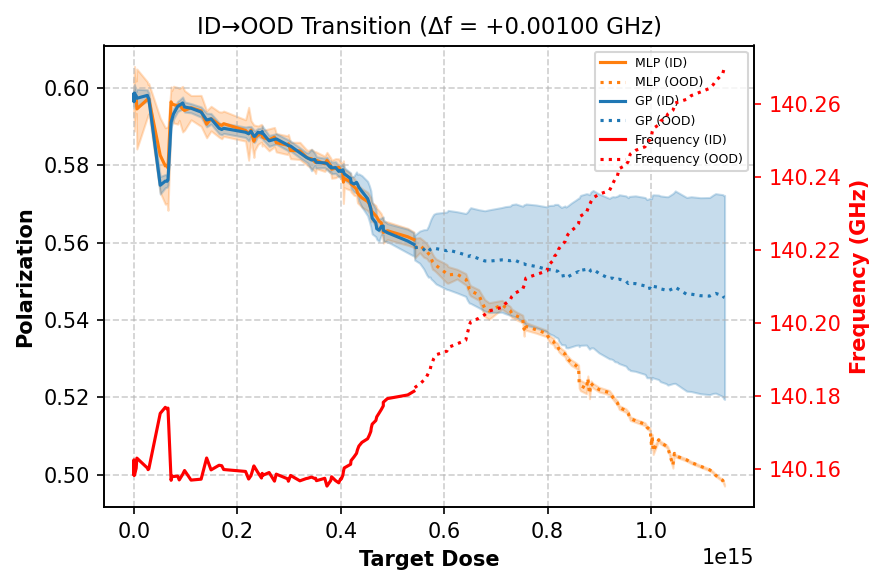

185


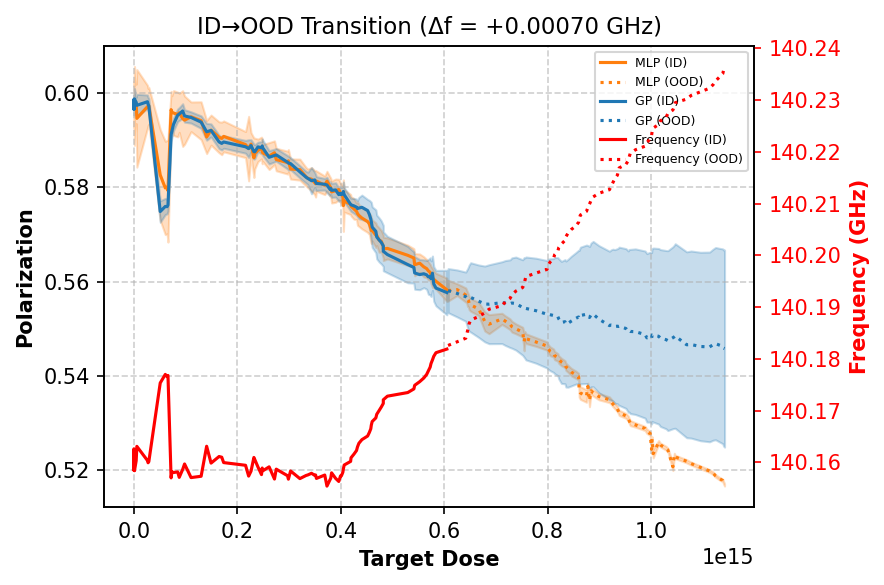

185


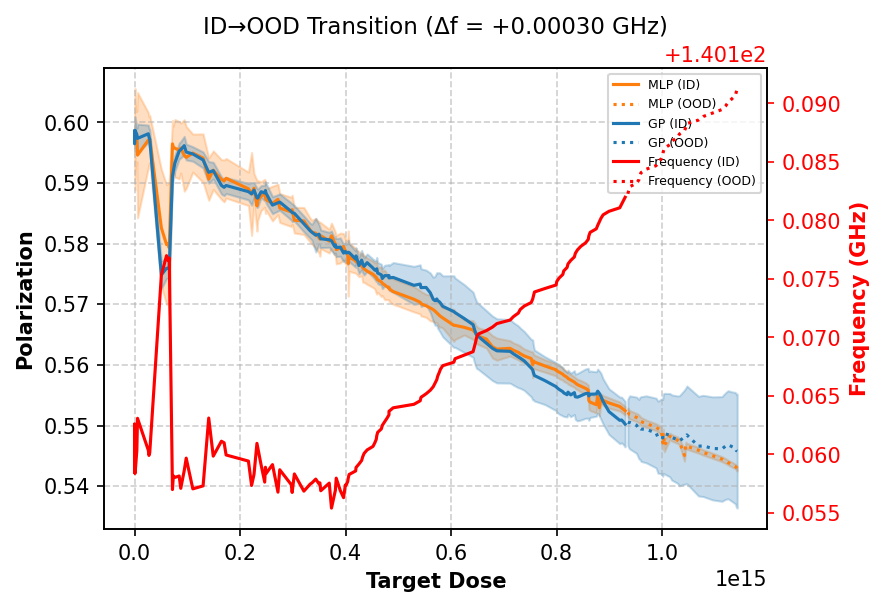

185


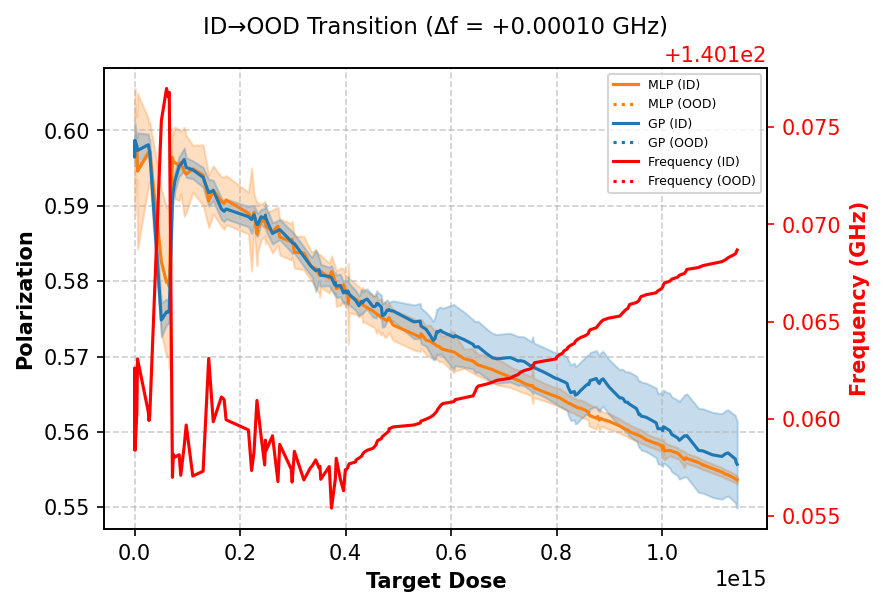

185


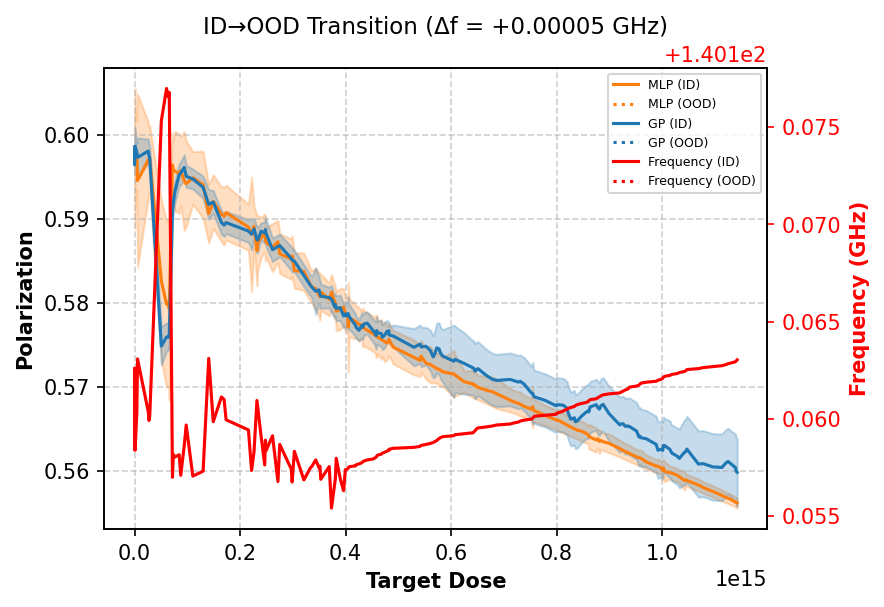

185


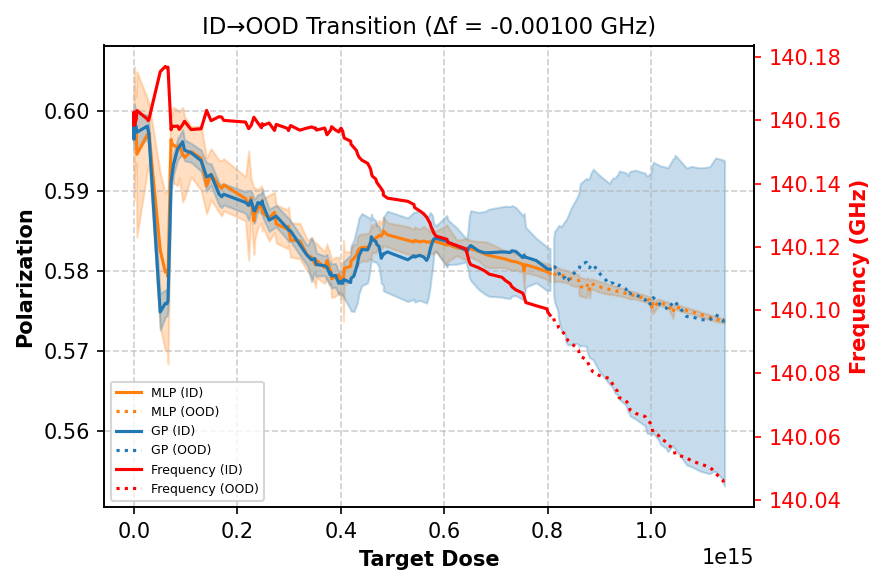

185


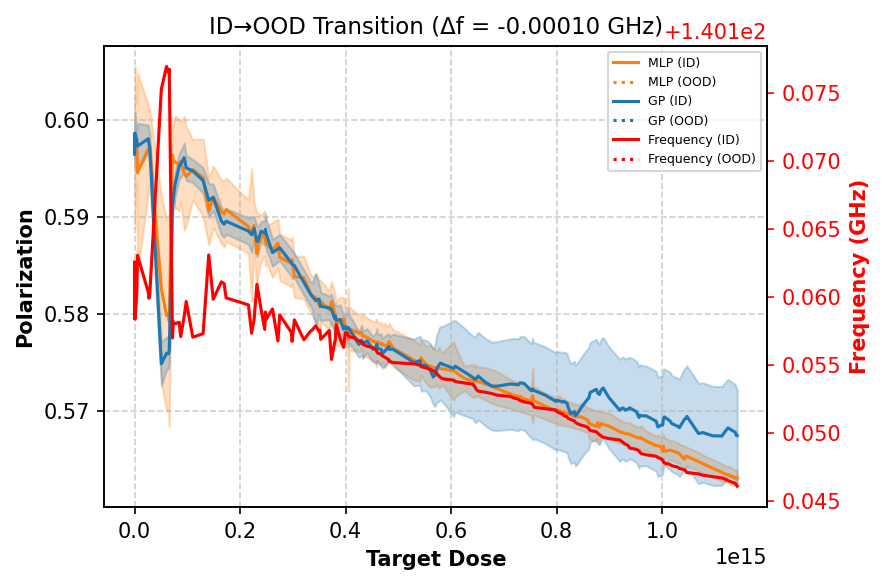

185


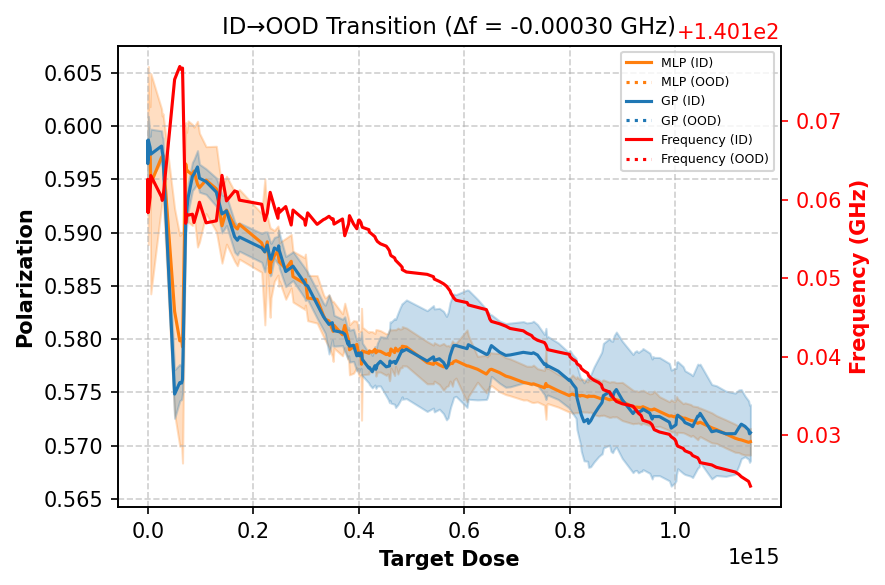

185


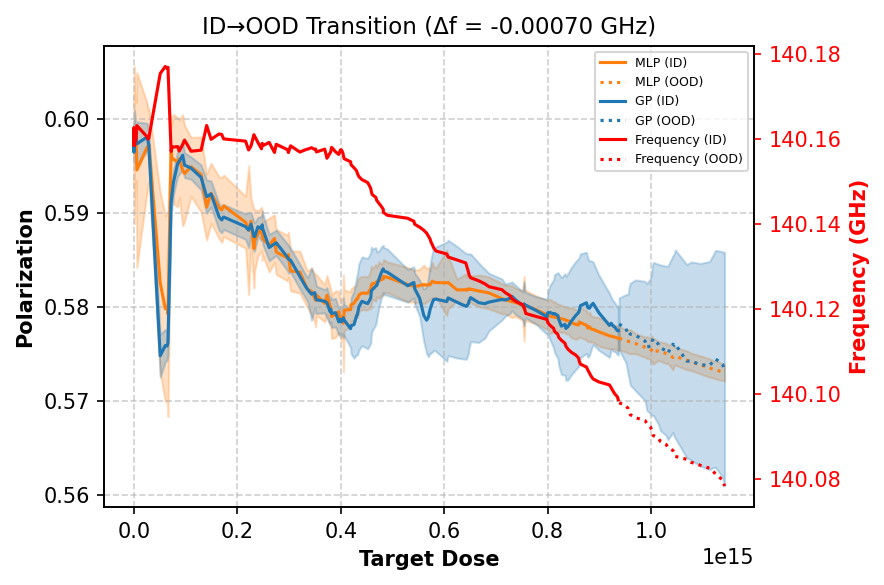

185


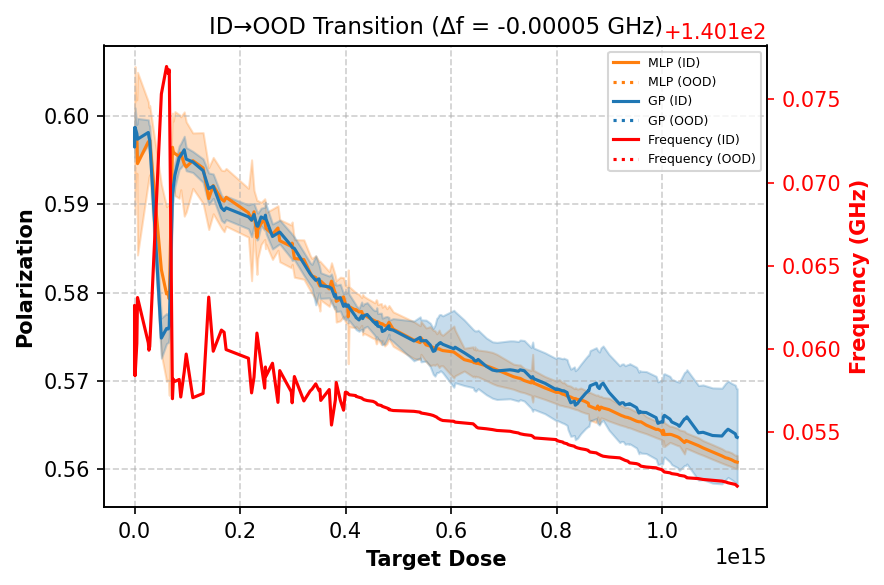

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# --- Increment/decrement list ---
increments = [0.001, 0.0007, 0.0003, 0.0001, 0.00005,
              -0.001, -0.0001, -0.0003, -0.0007, -0.00005]

# Original frequency
original_freq = filtered_test['uwave_freq'].copy()

# Upper and lower threshold frequencies
upper_threshold = 140.1822  # frequency above this → OOD
lower_threshold = 140.0979  # frequency below this → OOD

for inc in increments:
    temp = filtered_test.copy()
    temp['uwave_freq_OOD'] = original_freq.copy()

    # Dose threshold masks
    dose_threshold = 0.4e15
    mask_id = temp['TGT:PT12:Target_Dose'] <= dose_threshold
    mask_ood = temp['TGT:PT12:Target_Dose'] > dose_threshold
    num_ood = mask_ood.sum()

    # Increment/decrement OOD frequency
    if num_ood > 0:
        last_id_freq = original_freq[mask_id].iloc[-1]
        temp.loc[mask_ood, 'uwave_freq_OOD'] = last_id_freq + np.arange(num_ood) * inc

    # --- GP predictions ---
    Data_OOD = temp[['uwave_freq_OOD', 'TGT:PT12:Target_Dose','scaler_calc1']].values
    mean_pred_OOD, std_pred_OOD = gp_model.predict(Data_OOD)
    print(len(mean_pred_OOD))
    temp['mean_OOD'] = mean_pred_OOD
    temp['std_OOD'] = std_pred_OOD

    # --- MLP predictions ---
    temp["MLP_pred"] = X_test_final["Polarization_Prediction"]
    temp["MLP_std"] = X_test_final["Polarization_Prediction_std"]

    test_data_MLP_OOD = temp[['uwave_freq_OOD', 'TGT:PT12:Target_Dose', 'scaler_calc1']].values
    X_test_scaled_OOD = normalizer(test_data_MLP_OOD)
    preds_scaled_OOD = model(X_test_scaled_OOD)
    pred_mean_OOD = preds_scaled_OOD[:,0] * y_std + y_mean
    pred_std_OOD = tf.sqrt(tf.clip_by_value(tf.exp(preds_scaled_OOD[:,1]), 1e-10, 1e10)) * y_std
    temp["MLP_pred_OOD"] = pred_mean_OOD
    temp["MLP_std_OOD"] = pred_std_OOD

    # --- Extract data ---
    dose = temp['TGT:PT12:Target_Dose'].values
    freq = temp['uwave_freq_OOD'].values
    mlp = temp['MLP_pred_OOD'].values
    mlp_std = temp['MLP_std_OOD'].values
    gp = temp['mean_OOD'].values
    gp_std = temp['std_OOD'].values

    # --- ID / OOD masks based on frequency thresholds ---
    id_mask = (freq >= lower_threshold) & (freq <= upper_threshold)
    ood_mask = (freq > upper_threshold) | (freq < lower_threshold)

    fig, ax1 = plt.subplots(figsize=(6,4), dpi=150)

    # --- MLP ---
    ax1.plot(dose[id_mask], mlp[id_mask], color='tab:orange', linewidth=1.5, label='MLP (ID)')
    ax1.fill_between(dose[id_mask], mlp[id_mask]-2*mlp_std[id_mask], mlp[id_mask]+2*mlp_std[id_mask],
                     color='tab:orange', alpha=0.25)
    ax1.plot(dose[ood_mask], mlp[ood_mask], color='tab:orange', linestyle=':', linewidth=1.5, label='MLP (OOD)')
    ax1.fill_between(dose[ood_mask], mlp[ood_mask]-2*mlp_std[ood_mask], mlp[ood_mask]+2*mlp_std[ood_mask],
                     color='tab:orange', alpha=0.25)

    # --- GP ---
    ax1.plot(dose[id_mask], gp[id_mask], color='tab:blue', linewidth=1.5, label='GP (ID)')
    ax1.fill_between(dose[id_mask], gp[id_mask]-2*gp_std[id_mask], gp[id_mask]+2*gp_std[id_mask],
                     color='tab:blue', alpha=0.25)
    ax1.plot(dose[ood_mask], gp[ood_mask], color='tab:blue', linestyle=':', linewidth=1.5, label='GP (OOD)')
    ax1.fill_between(dose[ood_mask], gp[ood_mask]-2*gp_std[ood_mask], gp[ood_mask]+2*gp_std[ood_mask],
                     color='tab:blue', alpha=0.25)

    ax1.set_xlabel("Target Dose", fontweight='bold')
    ax1.set_ylabel("Polarization", fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Frequency line ---
    ax2 = ax1.twinx()
    ax2.plot(dose[id_mask], freq[id_mask], color='red', linewidth=1.5, label='Frequency (ID)')
    ax2.plot(dose[ood_mask], freq[ood_mask], color='red', linestyle=':', linewidth=1.5, label='Frequency (OOD)')
    ax2.set_ylabel("Frequency (GHz)", fontweight='bold', color='red')
    ax2.tick_params(axis='y', colors='red')

    # --- Combined legend ---
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=6)

    plt.title(f"ID→OOD Transition (Δf = {inc:+.5f} GHz)", fontsize=11)
    plt.tight_layout()
    plt.show()


In [6]:
import tensorflow as tf
print(tf.__version__)


2.20.0
